In [1]:
with open("corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

In [2]:
# character tokenizer

chars = sorted(list(set(corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

In [3]:
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 198
Characters: 	
 !"#$&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_abcdefghijklmnopqrstuvwxyz{|}~£·ÀÁÄÆÇÈÉËÍÒÖÚàáâäæçèéêëíîïñòóôöùúûüÿĩŒœΑΕΠΣΤΦΧάέήίαβγδεζηθικλμνξοπρςστυφχωόύώἀἄἅἐἔἥὀὁὍὐὑὗὰὲὴὶὸῖῦῶ–—‘’“”


In [4]:
import torch
import torch.nn as nn

# the transformer block with a triangular causal mask, no flash attention

class TransformerBlockManual(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.ln1(x)
        x = x + self.drop(
            self.attn(normed, normed, normed, attn_mask=mask)[0])
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        normed = self.ln1(x)

        q = self.W_q(normed)
        k = self.W_k(normed)
        v = self.W_v(normed)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        attn = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, dropout_p=self.drop.p, is_causal=True)

        attn = attn.transpose(1, 2).contiguous().view(B, T, C)
        attn = self.W_o(attn)

        x = x + self.drop(attn)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [6]:
def make_causal_mask(seq_len, device):
    # matrix where future positions are masked out
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [7]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, context_len, dropout=0.1, use_flash=True):
        super().__init__()
        self.use_flash = use_flash
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        block_class = TransformerBlock if use_flash else TransformerBlockManual
        self.blocks = nn.ModuleList([
            block_class(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        x = self.drop(self.token_emb(x) + self.pos_emb(positions))

        if self.use_flash:
            for block in self.blocks:
                x = block(x)
        else:
            mask = make_causal_mask(seq_len, x.device)
            for block in self.blocks:
                x = block(x, mask=mask)

        x = self.ln_final(x)
        return self.head(x)

In [8]:
context_len = 256

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT(vocab_size, 256, 8, 6, 1024, context_len).to(device)  # with flash attention

In [10]:
# encode the entire corpus
data = torch.tensor([char_to_idx[c] for c in corpus], dtype=torch.long)

# train/validation split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train tokens: {len(train_data)}")
print(f"Val tokens: {len(val_data)}")

Train tokens: 5458824
Val tokens: 606536


In [11]:
def get_batch(data, batch_size, context_len, device):
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

In [12]:
from google.colab import files

def generate(model, prompt, max_new_chars, device, temperature=1.0):
    model.eval()

    x = torch.tensor([char_to_idx[c] for c in prompt], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_chars):

            x_crop = x[:, -context_len:]
            logits = model(x_crop)

            logits = logits[:, -1, :] / temperature
            probs = torch.nn.functional.softmax(logits, dim=-1)
            next_char = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_char], dim=1)

    return ''.join([idx_to_char[i.item()] for i in x[0]])

In [13]:
from tqdm.notebook import tqdm
from google.colab import files

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
    lambda step: min(1.0, (step + 1) / 1000))

loss_fn = nn.CrossEntropyLoss()
n_steps = 20_000

train_losses = []
val_losses = []

for step in tqdm(range(1, n_steps + 1)):
    model.train()
    x_train, y_train = get_batch(train_data, 64, 256, device)

    logits = model(x_train)
    loss = loss_fn(logits.view(-1, vocab_size), y_train.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 250 == 0:
        model.eval()
        train_loss_avg = 0
        val_loss = 0
        with torch.no_grad():
            for _ in range(5):
                x_train_eval, y_train_eval = get_batch(train_data, 64, 256, device)
                train_logits = model(x_train_eval)
                train_loss_avg += loss_fn(
                    train_logits.view(-1, vocab_size),
                    y_train_eval.view(-1)
                ).item()

                x_val, y_val = get_batch(val_data, 64, 256, device)
                val_logits = model(x_val)
                val_loss += loss_fn(
                    val_logits.view(-1, vocab_size),
                    y_val.view(-1)
                ).item()

        train_loss_avg /= 5
        val_loss /= 5
        val_bpc = val_loss / 0.6931

        tqdm.write(f"step {step} | train loss {train_loss_avg:.4f} | val loss {val_loss:.4f} | val bpc {val_bpc:.4f}")
        train_losses.append(train_loss_avg)
        val_losses.append(val_loss)

    if step % 2000 == 0:
        sample = generate(model, prompt="There was a Boy whose name was Jim;\n", max_new_chars=500, device=device)
        tqdm.write(f"\n{sample}\n")
        torch.save(model.state_dict(), "model_extended_dataset.pt")
        files.download('model_extended_dataset.pt')

  0%|          | 0/20000 [00:00<?, ?it/s]

step 250 | train loss 2.7631 | val loss 2.8825 | val bpc 4.1588
step 500 | train loss 2.4812 | val loss 2.6105 | val bpc 3.7664
step 750 | train loss 2.3066 | val loss 2.4912 | val bpc 3.5942
step 1000 | train loss 2.1250 | val loss 2.2746 | val bpc 3.2818
step 1250 | train loss 2.0132 | val loss 2.1367 | val bpc 3.0828
step 1500 | train loss 1.9233 | val loss 2.0160 | val bpc 2.9087
step 1750 | train loss 1.8241 | val loss 1.9521 | val bpc 2.8164
step 2000 | train loss 1.7697 | val loss 1.8805 | val bpc 2.7132

There was a Boy whose name was Jim;
But he sonishil lined wallyce ta]mer!"

But the faur a side and entry and hert
  His is manest oe,
  But on hin there her procter;
"Sa!" and Mins aglosispone."
I have star
  "YeI'd theying any scam foar,
     AN MACGY SONT, I piRRISE
Sate'Sunteled the prass!”
    “He his fance!) I rew,
  I quillets adwerply fet upencands--
  By twlike manin 'ou!
           _Eendtelî_!

  "Hy, they Bet a Hus call'd a gat and Scriecres
   Undray his fimmils lie

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

step 2250 | train loss 1.7475 | val loss 1.8427 | val bpc 2.6587
step 2500 | train loss 1.6968 | val loss 1.7976 | val bpc 2.5936
step 2750 | train loss 1.6709 | val loss 1.7536 | val bpc 2.5301
step 3000 | train loss 1.6355 | val loss 1.7421 | val bpc 2.5135
step 3250 | train loss 1.6121 | val loss 1.7083 | val bpc 2.4648
step 3500 | train loss 1.5766 | val loss 1.6751 | val bpc 2.4168
step 3750 | train loss 1.5656 | val loss 1.6467 | val bpc 2.3759
step 4000 | train loss 1.5332 | val loss 1.6274 | val bpc 2.3481

There was a Boy whose name was Jim;
  Which a doon have Lenteen's who espage,
  The larger had made on the besing words--
  Soul, pull, h'' mark a break of jamit_.









JAPS ANNER COUNS.


By where, theree! Binds Poster,
  To make my recloim in sea,
  As now, like the that Mape and years are
Full if the fear if her prithected, and small!

And Amaskwarkied hour an' lase then;
  But he'd sen to joust his lost the
  To pass respect persied her;
  Yet never something down he

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

step 18250 | train loss 1.1733 | val loss 1.3941 | val bpc 2.0114
step 18500 | train loss 1.1666 | val loss 1.3730 | val bpc 1.9810
step 18750 | train loss 1.1816 | val loss 1.3757 | val bpc 1.9848
step 19000 | train loss 1.1501 | val loss 1.3712 | val bpc 1.9784
step 19250 | train loss 1.1370 | val loss 1.4096 | val bpc 2.0337
step 19500 | train loss 1.1409 | val loss 1.4019 | val bpc 2.0226
step 19750 | train loss 1.1748 | val loss 1.3897 | val bpc 2.0051
step 20000 | train loss 1.1595 | val loss 1.3850 | val bpc 1.9983

There was a Boy whose name was Jim;

             The stray was hurried a head
                  To have the taste numberie

                          With fears in her mother head:

                 Or even that he red;  I eat
    With a top of fightingarina,

                "Yes answer when a water streams

     To the Chose of the Gublins delight married

                                           Enwraph'd

                                  SOME Day Phostoct

  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

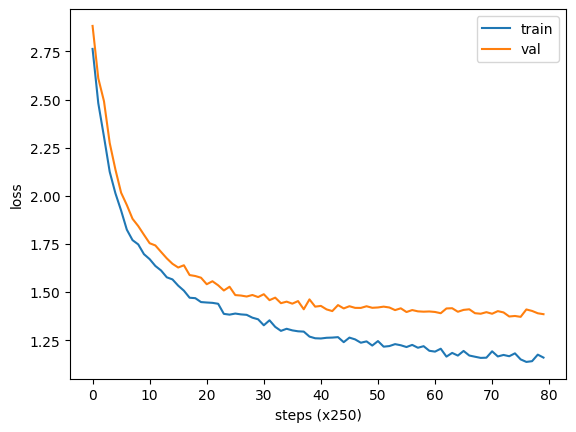

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.xlabel('steps (x250)')
plt.ylabel('loss')
plt.show()